In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('creditcard.csv')

# Scaling
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

# Split
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Handling Class Imbalance (SMOTE)

In this step, we address the class imbalance problem using SMOTE (Synthetic Minority Over-sampling Technique).

#  Why SMOTE?

- The dataset is highly imbalanced (fraud < 1%)
- Models trained on imbalanced data tend to ignore minority class

#  What SMOTE does:
- Generates synthetic samples for the minority class
- Balances the dataset without simple duplication

#  Benefit:
- Improves model’s ability to detect fraud (higher recall)

# Important Rule

SMOTE is applied only on the training dataset to prevent data leakage and ensure proper model evaluation.

In [6]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply on training data only
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check distribution
print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_res.value_counts())

Before SMOTE:
 Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
 Class
0    227451
1    227451
Name: count, dtype: int64


# Results After SMOTE

- Before SMOTE:
  - Majority class (normal) heavily dominates
  - Minority class (fraud) is very small

- After SMOTE:
  - Both classes are perfectly balanced
  - The model can now learn fraud patterns effectively

# Key Insight:
Balancing the dataset helps improve recall, which is critical for fraud detection problems.

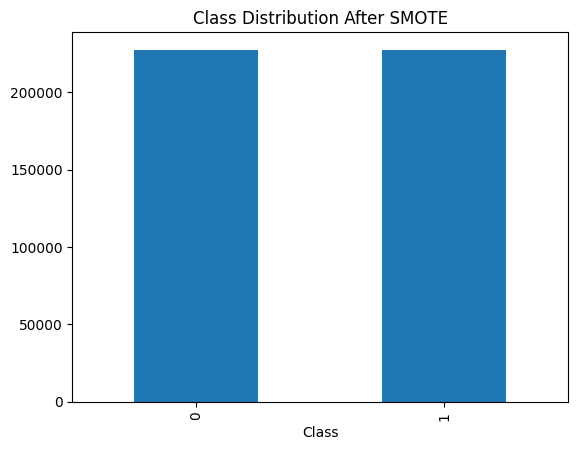

In [7]:
import matplotlib.pyplot as plt

y_train_res.value_counts().plot(kind='bar')
plt.title("Class Distribution After SMOTE")
plt.show()

The plot shows that both classes are now equally represented after applying SMOTE.